In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('C:\\Users\\Mahadeva\\OneDrive\\Desktop\\AI City intelligence\\data\\raw\\Air_quality_data.csv');print(df.columns.tolist())

['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI', 'AQI_Bucket']


In [4]:
df.head(10)

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor
5,Delhi,2015-01-02,344.2,173.2,179.8,128.4,156.1,15.6,6.28,7.5,9.4,494.2,Severe
6,Mumbai,2015-01-02,59.2,335.7,182.1,143.8,207.3,44.8,5.81,6.4,145.5,285.7,Poor
7,Chennai,2015-01-02,418.9,573.8,23.8,17.5,43.0,22.5,4.49,9.5,198.7,276.4,Poor
8,Kolkata,2015-01-02,329.8,599.3,139.1,34.0,75.2,24.1,3.63,63.4,111.2,479.8,Severe
9,Bangalore,2015-01-02,22.5,317.5,163.0,62.4,130.9,46.7,0.00,59.7,49.8,267.5,Poor


In [5]:
df.shape


(18265, 13)

In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  str    
 1   Datetime    18265 non-null  str    
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  AQI         18265 non-null  float64
 12  AQI_Bucket  18265 non-null  str    
dtypes: float64(10), str(3)
memory usage: 1.8 MB


City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
AQI           0
AQI_Bucket    0
dtype: int64

 AQI Distribution|
 

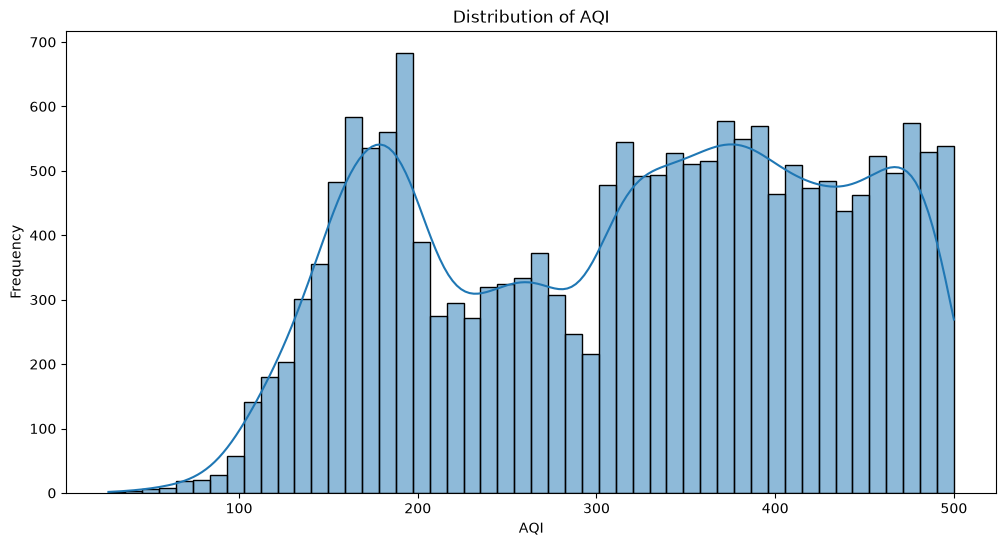

In [7]:
plt.figure(figsize=(12, 6))

sns.histplot(df["AQI"].dropna(), bins=50, kde=True)

plt.title("Distribution of AQI")
plt.xlabel("AQI") 
plt.ylabel("Frequency")
plt.show()

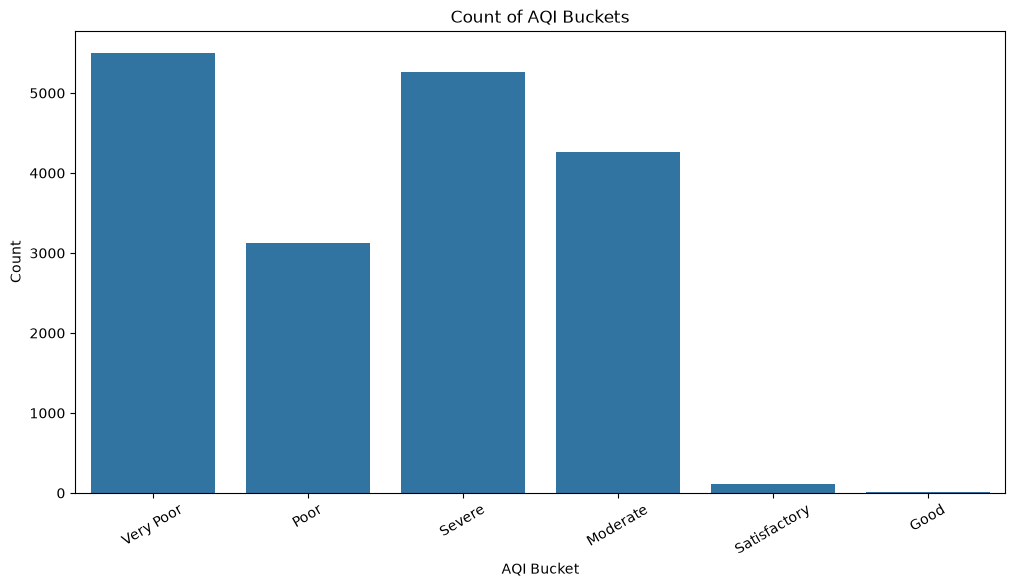

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="AQI_Bucket")

plt.title("Count of AQI Buckets")
plt.xlabel("AQI Bucket")
plt.ylabel("Count")
plt.xticks(rotation=30) 
plt.show()

In [9]:
df["datetime"] = pd.to_datetime(df["Datetime"], errors='coerce')
print(df["datetime"].head().dtypes)


datetime64[us]


In [12]:
df["Year"] = df["datetime"].dt.year
df["Month"] = df["datetime"].dt.month
df["Day"] = df["datetime"].dt.day
df["Hour"] = df["datetime"].dt.hour   
df["Day_of_Week"] = df["datetime"].dt.dayofweek

In [14]:
df["City"].unique()

<StringArray>
['Delhi', 'Mumbai', 'Chennai', 'Kolkata', 'Bangalore']
Length: 5, dtype: str

In [15]:
city_aqi = df.groupby("City")["AQI"].mean().sort_values(ascending=False)

In [16]:
city_aqi

City
Mumbai       318.184834
Kolkata      317.726992
Delhi        317.724719
Bangalore    317.270271
Chennai      316.619244
Name: AQI, dtype: float64

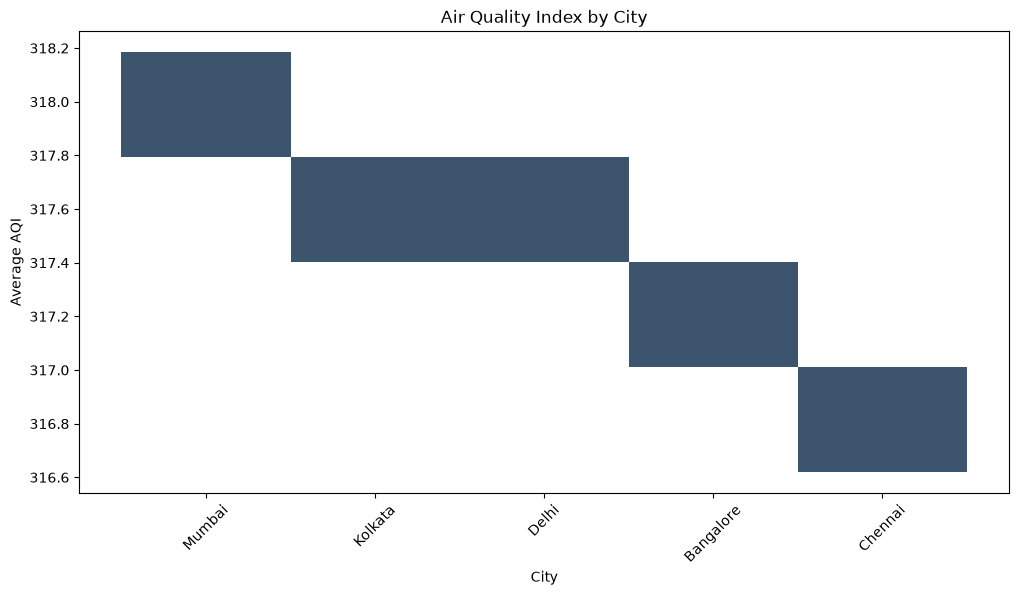

In [18]:
plt.figure(figsize=(12, 6))
sns.histplot(x=city_aqi.index, y=city_aqi.values)
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.title("Air Quality Index by City")
plt.xticks(rotation=45)
plt.show()

In [19]:
df.isnull().sum()

City           0
Datetime       0
PM2.5          0
PM10           0
NO             0
NO2            0
NOx            0
NH3            0
CO             0
SO2            0
O3             0
AQI            0
AQI_Bucket     0
datetime       0
Year           0
Month          0
Day            0
Hour           0
Day_of_Week    0
dtype: int64

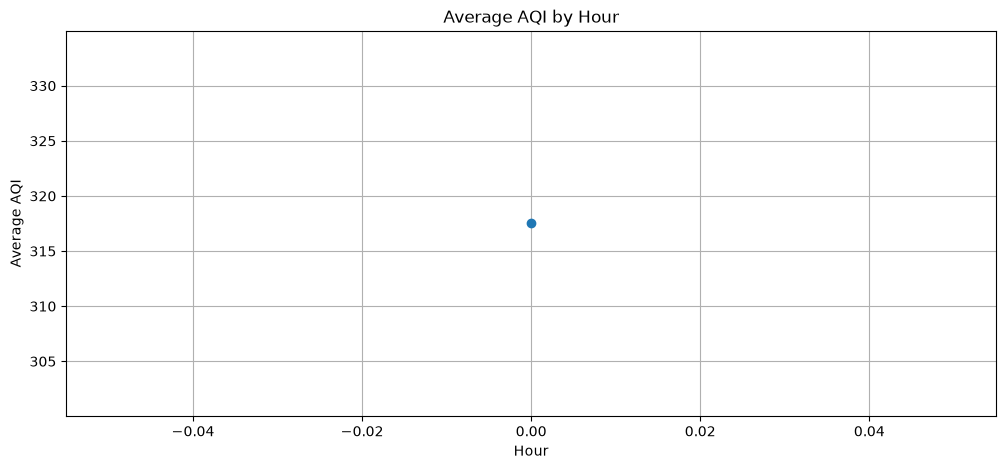

In [20]:
hourly_aqi = df.groupby("Hour")["AQI"].mean()

plt.figure(figsize=(12, 5))
hourly_aqi.plot(marker="o")
plt.title("Average AQI by Hour")
plt.xlabel("Hour")
plt.ylabel("Average AQI")
plt.grid()
plt.show()

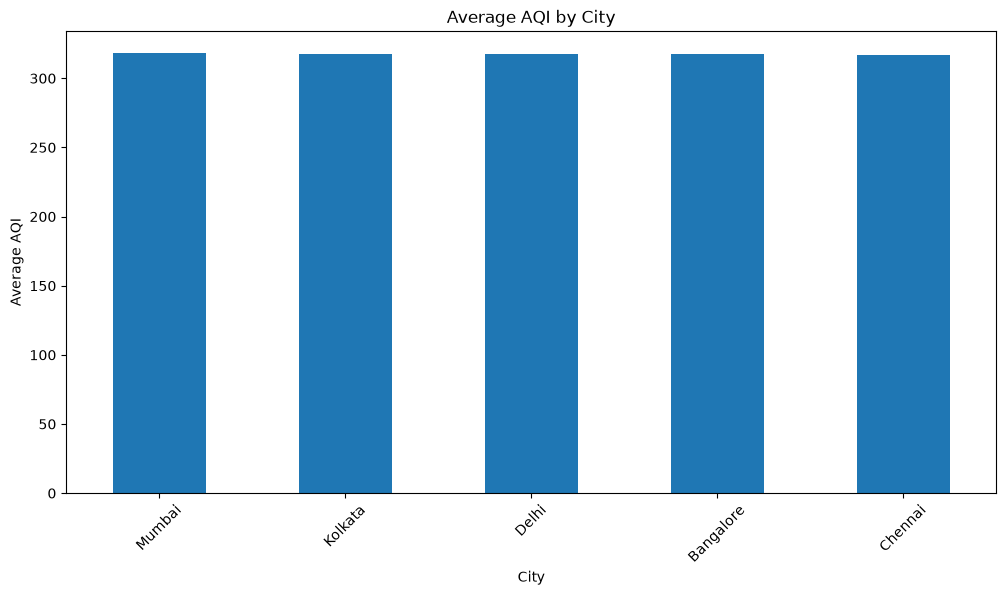

In [21]:
city_aqi = (
    df.groupby("City")["AQI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
city_aqi.plot(kind="bar")
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show()

In [22]:
# Remove rows where the target or datetime is missing
df = df.dropna(subset=["AQI", "datetime"]).copy()

# Features used to predict AQI
features = [
    "City",
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Year",
    "Month",
    "Day",
    "Hour",
    "Day_of_Week"
]

target = "AQI"

X = df[features].copy()
y = df[target].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
X.head()

Feature shape: (18265, 15)
Target shape: (18265,)


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Year,Month,Day,Hour,Day_of_Week
0,Delhi,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,2015,1,1,0,3
1,Mumbai,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2015,1,1,0,3
2,Chennai,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,2015,1,1,0,3
3,Kolkata,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,2015,1,1,0,3
4,Bangalore,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,2015,1,1,0,3


In [23]:
from sklearn.preprocessing import LabelEncoder

city_encoder = LabelEncoder()

X["City"] = city_encoder.fit_transform(X["City"])

print(dict(zip(city_encoder.classes_, city_encoder.transform(city_encoder.classes_))))

{'Bangalore': np.int64(0), 'Chennai': np.int64(1), 'Delhi': np.int64(2), 'Kolkata': np.int64(3), 'Mumbai': np.int64(4)}


In [24]:
df = df.sort_values("datetime").reset_index(drop=True)

X = df[features].copy()
X["City"] = city_encoder.transform(X["City"])

y = df[target].copy()

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("training data:",
 X_train.shape, y_train.shape)
print("testing data:",
 X_test.shape, y_test.shape)

training data: (14612, 15) (14612,)
testing data: (3653, 15) (3653,)


In [25]:
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Evaluation Metrics:")
print(f"Linear Regression MAE: {linear_mae:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²: {linear_r2:.4f}")

Linear Regression Evaluation Metrics:
Linear Regression MAE: 95.59
Linear Regression RMSE: 110.82
Linear Regression R²: 0.0565


In [26]:
from xgboost import XGBRegressor

aqi_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

aqi_xgb_model.fit(X_train, y_train)

xgb_predictions = aqi_xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost results")
print(f"MAE : {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"R²  : {xgb_r2:.4f}")

XGBoost results
MAE : 6.26
RMSE: 17.29
R²  : 0.9770


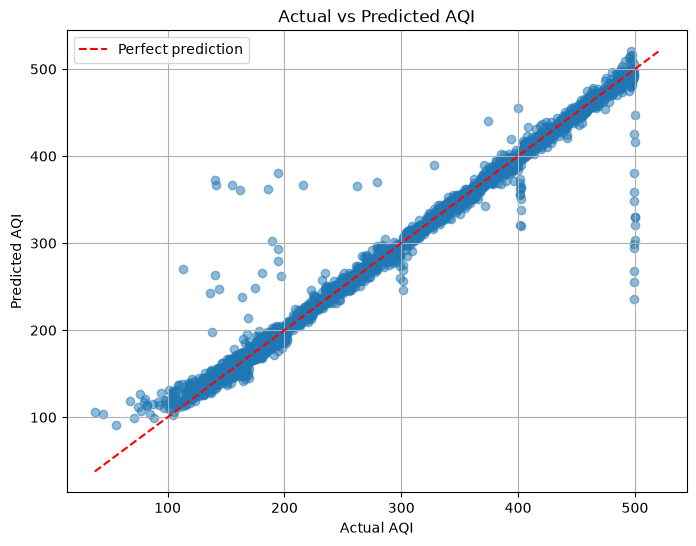

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, xgb_predictions, alpha=0.5)

min_value = min(y_test.min(), xgb_predictions.min())
max_value = max(y_test.max(), xgb_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Actual vs Predicted AQI")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.legend()
plt.grid()
plt.show()

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": aqi_xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance)

        Feature  Importance
1         PM2.5    0.574295
2          PM10    0.305376
9            O3    0.034382
7            CO    0.013988
12          Day    0.011369
14  Day_of_Week    0.008184
8           SO2    0.007562
5           NOx    0.007398
3            NO    0.007112
4           NO2    0.007080
6           NH3    0.007075
11        Month    0.006765
10         Year    0.005722
0          City    0.003692
13         Hour    0.000000


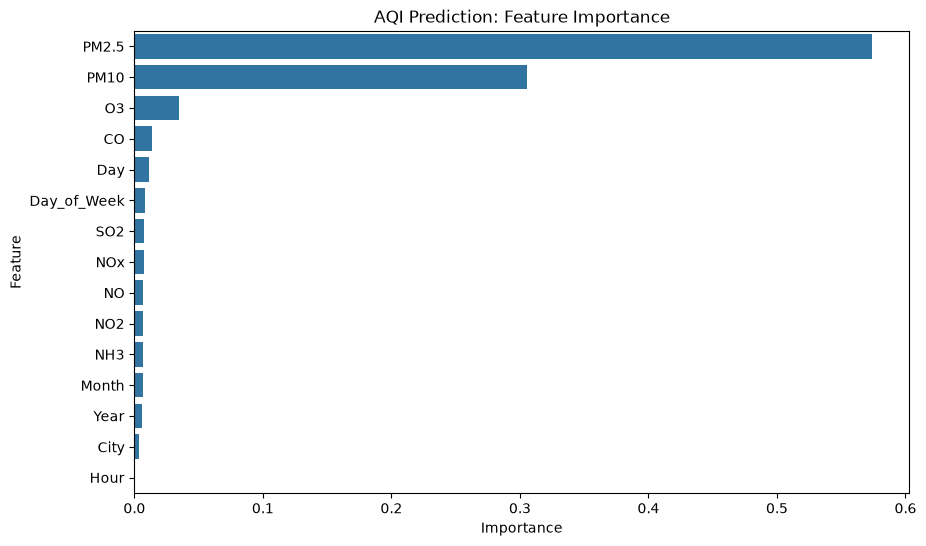

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("AQI Prediction: Feature Importance")
plt.show()

In [30]:
comparison = pd.DataFrame({
    "Actual_AQI": y_test.values,
    "Predicted_AQI": np.round(xgb_predictions, 1),
    "Absolute_Error": np.round(
        np.abs(y_test.values - xgb_predictions), 1
    )
})

comparison.head(10)

,Actual_AQI,Predicted_AQI,Absolute_Error
0,435.2,432.899994,2.3
1,174.1,166.600006,7.5
2,234.5,239.000000,4.5
3,495.1,492.299988,2.8
4,380.2,382.200012,2.0
5,189.4,180.500000,8.9
6,209.1,224.600006,15.5
7,407.5,406.100006,1.4
8,172.8,177.500000,4.7
9,310.4,311.899994,1.5


In [31]:
comparison.sort_values("Absolute_Error", ascending=False).head(10)

,Actual_AQI,Predicted_AQI,Absolute_Error
1600,499.3,235.300003,264.0
1799,499.1,255.300003,243.8
3238,140.9,372.899994,232.0
2086,499.1,267.600006,231.5
3167,141.5,366.899994,225.4
2477,155.0,367.200012,212.2
581,499.4,294.100006,205.3
2769,499.2,298.500000,200.7
214,162.2,360.799988,198.6
2287,499.7,303.600006,196.1


In [32]:
def get_aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    return "Severe"

In [33]:
comparison["AQI_Category"] = comparison["Predicted_AQI"].apply(
    get_aqi_category
)

comparison.head(10)

,Actual_AQI,Predicted_AQI,Absolute_Error,AQI_Category
0,435.2,432.899994,2.3,Severe
1,174.1,166.600006,7.5,Moderate
2,234.5,239.000000,4.5,Poor
3,495.1,492.299988,2.8,Severe
4,380.2,382.200012,2.0,Very Poor
5,189.4,180.500000,8.9,Moderate
6,209.1,224.600006,15.5,Poor
7,407.5,406.100006,1.4,Severe
8,172.8,177.500000,4.7,Moderate
9,310.4,311.899994,1.5,Very Poor


In [34]:
def calculate_aqi_risk(aqi):
    return min(100, round((aqi / 500) * 100))

comparison["Risk_Score"] = comparison["Predicted_AQI"].apply(
    calculate_aqi_risk
)

comparison.head(10)

,Actual_AQI,Predicted_AQI,Absolute_Error,AQI_Category,Risk_Score
0,435.2,432.899994,2.3,Severe,87
1,174.1,166.600006,7.5,Moderate,33
2,234.5,239.000000,4.5,Poor,48
3,495.1,492.299988,2.8,Severe,98
4,380.2,382.200012,2.0,Very Poor,76
5,189.4,180.500000,8.9,Moderate,36
6,209.1,224.600006,15.5,Poor,45
7,407.5,406.100006,1.4,Severe,81
8,172.8,177.500000,4.7,Moderate,36
9,310.4,311.899994,1.5,Very Poor,62


In [35]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(aqi_xgb_model, "models/aqi_xgboost_model.joblib")
joblib.dump(city_encoder, "models/aqi_city_encoder.joblib")
joblib.dump(features, "models/aqi_features.joblib")

print("AQI model, city encoder, and feature list saved successfully.")

AQI model, city encoder, and feature list saved successfully.


In [36]:
loaded_model = joblib.load("models/aqi_xgboost_model.joblib")
loaded_encoder = joblib.load("models/aqi_city_encoder.joblib")
loaded_features = joblib.load("models/aqi_features.joblib")

print("Model:", type(loaded_model).__name__)
print("Cities:", list(loaded_encoder.classes_))
print("Features:", loaded_features)

Model: XGBRegressor
Cities: ['Bangalore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai']
Features: ['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week']


In [ ]:
sample = X_test.iloc[[0]]

predicted_aqi = loaded_model.predict(sample)[0]

print("Actual AQI:", round(y_test.iloc[0], 1))
print("Predicted AQI:", round(predicted_aqi, 1))
print("AQI Category:", get_aqi_category(predicted_aqi))
print("Risk Score:", calculate_aqi_risk(predicted_aqi))

Actual AQI: 435.2
Predicted AQI: 432.9
AQI Category: Severe
Risk Score: 87


: 